In [3]:
import numpy as np
import matplotlib.pyplot as plt
#创建训练使用回归模型
from sklearn.linear_model import LinearRegression

In [25]:
num = 50
np.random.seed(0)
x_data = np.random.uniform(0,10,num)
y_data = 0.5 * x_data + 1 + np.random.normal(0,1,num)

In [27]:
x_data = x_data.reshape((-1,1))
#调整为列向量 -1表示自动推断行数量 1表示只有一列

In [29]:
data = np.column_stack([x_data,y_data])
#因为堆叠必须为二维,所以x_data将转换为二维方便y_data的这种一维数据堆叠

In [33]:
#创建回归对象并拟合
#面相对象设计语言,先创建对象,再调用方法,拟合后存取数据可以进行预测查看等
#与其他对象不冲突
#逻辑为先配置,再训练
LR = LinearRegression()
LR.fit(x_data,y_data)

LinearRegression()

In [35]:
slope = LR.coef_ #返回全部的斜率,一组X_data输出一个斜率
intercept = LR.intercept_

In [41]:
x_array = np.linspace(0,10,101).reshape((-1,1))
predicted = LR.predict(x_array)

In [43]:
data_ = np.column_stack([x_data,LR.predict(x_data)])

(-2.0, 8.0)

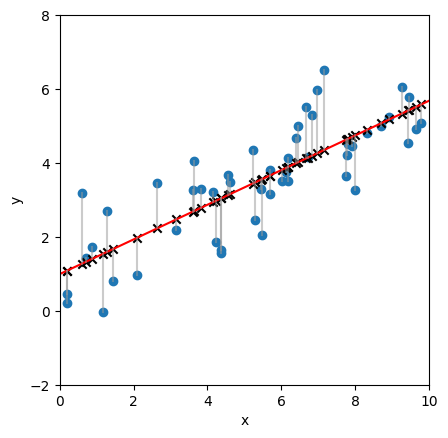

In [51]:
fig,ax = plt.subplots()
ax.scatter(x_data,y_data)
ax.scatter(x_data,LR.predict(x_data),color = 'k',marker = 'x')
#用直线连接相近的点
ax.plot(x_array,predicted,color='r')
ax.plot(([i for (i,j) in data_] , [i for (i,j) in data]),
        ([j for (i,j) in data_] , [j for (i,j) in data]),
        #这里plot知道给的x和y下面分别有两个数组,知道绘制线段,每一个元组的两列,第一列为起点,第二列为终点,一次x一次y就变成了对应点
        c = [0.6,0.6,0.6],alpha = 0.5)
ax.set_xlabel('x');ax.set_ylabel('y')
ax.set_aspect('equal',adjustable = 'box')
#equal表示xy单位相等
ax.set_xlim(0,10);ax.set_ylim(-2,8)

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [63]:
np.random.seed(0)
n_samples = 100
X = np.random.randn(n_samples,2)
#标准正太分布 生成两组X  x1,x2  
y = -3 * X[:,0] + 2*X[:,1] +1 +0.5*np.random.randn(n_samples)

In [71]:
LR = LinearRegression()
y_predicted = LR.fit(X,y)

In [73]:
slope = LR.coef_
intercept = LR.intercept_

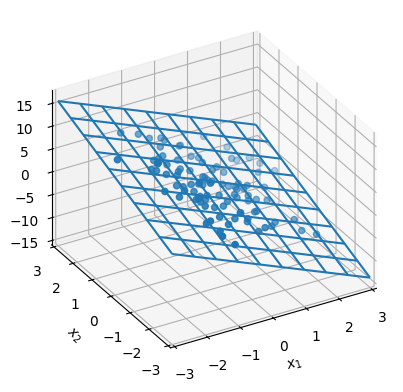

In [105]:
fig = plt.figure()
ax = fig.add_subplot(111,projection = '3d')
ax.scatter(X[:,0],X[:,1],y)

#生成回归平面的数据点 两组,分别为10*10
x1_grid,x2_grid = np.meshgrid(np.linspace(-3,3,10),
                              np.linspace(-3,3,10))
#flatten将10*10的数组拉成一维,然后堆叠成对应点的坐标
#参数要求为可迭代对象,所以将两个数组堆叠 相当于将两个数组变成(100,2)的大小
X_grid = np.column_stack((x1_grid.flatten(),x2_grid.flatten()))

#将坐标传递给已训练的回归模型LR 这里输出的形状为100,1
y_pred = LR.predict(X_grid)
#将调整形状与数组形状相同 变为10,10
y_pred = y_pred.reshape(x1_grid.shape)

#绘制回归平面,线框格式
ax.plot_wireframe(x1_grid,x2_grid,y_pred)

ax.set_xlabel('$x_1$');ax.set_ylabel('$x_2$')
ax.set_zlabel('y')

ax.set_xlim([-3,3]);ax.set_ylim([-3,3])
#平行投影 z轴逆时针旋转120度,垂直抬高30°
ax.set_proj_type('ortho');ax.view_init(azim = -120,elev=30)